#  Autism Screening in Adults- Data science Project




## 1. Data Loading

Import libraries and load the raw dataset.

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)
n = 704

a_scores = {f'A{i}_Score': np.random.randint(0, 2, n) for i in range(1, 11)}

ethnicities = ['White-European', 'Latino', 'Others', 'Black', 'Asian',
               'Middle Eastern', 'Pasifika', 'South Asian', 'Hispanic',
               'Turkish', '?', 'others']
countries   = ['United States', 'Brazil', 'Spain', 'Egypt', 'New Zealand',
               'Bahrain', 'Australia', 'India', 'United Kingdom', 'Jordan',
               'Ireland', 'United Arab Emirates', 'Iceland', 'Others']

# Build age column with a small proportion of missing values
_age_pool  = list(range(17, 65)) + [None]          # 49 values
_age_probs = [0.97 / 48] * 48 + [0.03]
_age_idx   = np.random.choice(len(_age_pool), n, p=_age_probs)
age_col    = [_age_pool[i] for i in _age_idx]

data = {
    **a_scores,
    'age':             age_col,
    'gender':          np.random.choice(['m', 'f'], n),
    'ethnicity':       np.random.choice(ethnicities, n),
    'jundice':         np.random.choice(['yes', 'no'], n),
    'austim':          np.random.choice(['yes', 'no'], n),
    'contry_of_res':   np.random.choice(countries, n),
    'used_app_before': np.random.choice(['yes', 'no'], n),
    'result':          np.random.randint(0, 11, n),
    'age_desc':        ['18 and more'] * n,
    'relation':        np.random.choice(['Self', 'Parent', 'Health care professional',
                                         'Relative', 'Others'], n),
    'Class/ASD':       np.random.choice(['YES', 'NO'], n, p=[0.4, 0.6]),
}

df = pd.DataFrame(data)
print(df.head(10))


   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         0         0         0         1         1         0         1   
1         1         0         1         0         0         0         1   
2         0         1         1         0         0         1         0   
3         0         1         1         1         1         1         1   
4         0         1         0         0         1         0         1   
5         1         1         1         1         0         0         1   
6         0         0         1         0         0         1         0   
7         0         1         1         1         1         1         0   
8         0         0         0         1         1         1         1   
9         1         1         0         1         1         1         1   

   A8_Score  A9_Score  A10_Score  ...  gender    ethnicity jundice austim  \
0         1         1          0  ...       m  South Asian      no    yes   
1         0         

> Imports core libraries and reads the raw autism screening CSV file into a DataFrame.

## 2. Initial Data Inspection

Check the shape and summary statistics of the dataset.

In [3]:
print(df.shape)

(704, 21)


> Prints the number of rows and columns in the dataset.

In [4]:
print(df.describe())

         A1_Score    A2_Score    A3_Score    A4_Score    A5_Score    A6_Score  \
count  704.000000  704.000000  704.000000  704.000000  704.000000  704.000000   
mean     0.524148    0.477273    0.471591    0.508523    0.508523    0.531250   
std      0.499772    0.499838    0.499547    0.500283    0.500283    0.499377   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      1.000000    0.000000    0.000000    1.000000    1.000000    1.000000   
75%      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

         A7_Score    A8_Score    A9_Score   A10_Score         age      result  
count  704.000000  704.000000  704.000000  704.000000  686.000000  704.000000  
mean     0.474432    0.501420    0.475852    0.485795   39.768222    5.009943  
std      0.499701    0.500353 

> Shows basic statistics (mean, min, max, etc.) for all numeric columns.

### 2.1 Target Column Distribution

Inspect the balance of the target column `Class/ASD`.

In [5]:
print(df["Class/ASD"].value_counts())
#TARGET COLUMN

Class/ASD
NO     402
YES    302
Name: count, dtype: int64


> Counts how many individuals were screened as ASD-positive vs negative — tells us if the dataset is balanced.

### 2.2 Missing Values & Unique Entries

In [6]:
print(df.isnull().sum())

A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                18
gender              0
ethnicity           0
jundice             0
austim              0
contry_of_res       0
used_app_before     0
result              0
age_desc            0
relation            0
Class/ASD           0
dtype: int64


> Checks for any missing (null) values across all columns.

In [7]:
for col in df.columns:
    print(col, df[col].unique())


A1_Score [0 1]
A2_Score [0 1]
A3_Score [0 1]
A4_Score [1 0]
A5_Score [1 0]
A6_Score [0 1]
A7_Score [1 0]
A8_Score [1 0]
A9_Score [1 0]
A10_Score [0 1]
age [28. 40. 30. 21. 25. 24. nan 54. 64. 38. 56. 33. 31. 23. 29. 34. 50. 20.
 27. 57. 59. 44. 45. 42. 47. 41. 39. 32. 19. 37. 52. 55. 43. 58. 61. 35.
 26. 53. 48. 49. 62. 60. 17. 18. 46. 36. 22. 63. 51.]
gender ['m' 'f']
ethnicity ['South Asian' 'others' 'Pasifika' 'Asian' 'Turkish' 'Others' 'Hispanic'
 'Latino' 'Black' 'White-European' 'Middle Eastern' '?']
jundice ['no' 'yes']
austim ['yes' 'no']
contry_of_res ['Brazil' 'Spain' 'United Kingdom' 'Ireland' 'New Zealand' 'Egypt'
 'United Arab Emirates' 'Iceland' 'Australia' 'Others' 'United States'
 'Jordan' 'Bahrain' 'India']
used_app_before ['yes' 'no']
result [ 8  2  3  6  9  4  7  0  1 10  5]
age_desc ['18 and more']
relation ['Others' 'Relative' 'Health care professional' 'Self' 'Parent']
Class/ASD ['NO' 'YES']


> Lists every unique value in each column to spot inconsistencies or unexpected entries.

### 2.3 Target Class Visualisation

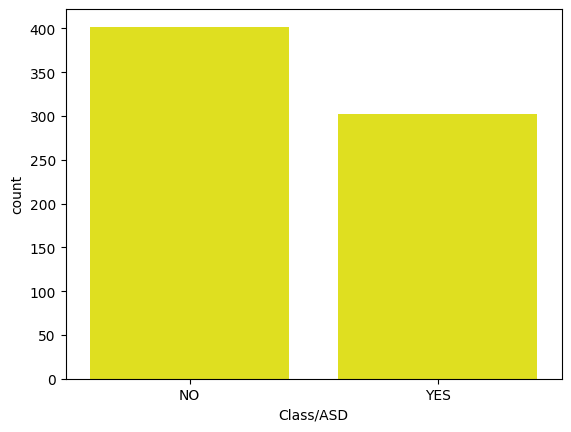

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class/ASD", data=df, color="yellow")
plt.show()

> Plots a bar chart showing the count of each class label (ASD / No ASD).

## 3. Data Cleaning

Rename columns, standardise casing, encode the target, handle missing values, and drop irrelevant columns.

### 3.1 Rename Columns

Fix typos and rename columns to consistent names.

In [9]:
df = df.rename(columns={
    'contry_of_res': 'country_of_res',
    'jundice':       'jaundice',
    'austim':        'autism',
    'Class/ASD':     'Class'
})
df.head(5)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,Class
0,0,0,0,1,1,0,1,1,1,0,...,m,South Asian,no,yes,Brazil,yes,8,18 and more,Others,NO
1,1,0,1,0,0,0,1,0,1,0,...,f,others,yes,no,Spain,yes,2,18 and more,Relative,NO
2,0,1,1,0,0,1,0,0,0,1,...,f,Pasifika,no,no,United Kingdom,yes,3,18 and more,Health care professional,YES
3,0,1,1,1,1,1,1,0,0,1,...,m,Pasifika,yes,yes,Spain,no,3,18 and more,Health care professional,NO
4,0,1,0,0,1,0,1,0,1,1,...,f,South Asian,no,yes,Ireland,no,8,18 and more,Relative,YES


> Fixes column name typos (e.g. 'jundice' → 'jaundice') and renames the target column to 'Class'.

### 3.2 Inspect Categorical Columns & Standardise Column Names

In [10]:
print(df["gender"].unique())
print(df["ethnicity"].unique())
print(df["country_of_res"].unique())

['m' 'f']
['South Asian' 'others' 'Pasifika' 'Asian' 'Turkish' 'Others' 'Hispanic'
 'Latino' 'Black' 'White-European' 'Middle Eastern' '?']
['Brazil' 'Spain' 'United Kingdom' 'Ireland' 'New Zealand' 'Egypt'
 'United Arab Emirates' 'Iceland' 'Australia' 'Others' 'United States'
 'Jordan' 'Bahrain' 'India']


> Prints unique values in gender, ethnicity, and country columns to detect any inconsistent formatting.

In [11]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)
#CASE CONSISTENCY

Index(['a1_score', 'a2_score', 'a3_score', 'a4_score', 'a5_score', 'a6_score',
       'a7_score', 'a8_score', 'a9_score', 'a10_score', 'age', 'gender',
       'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'class'],
      dtype='object')


> Converts all column names to lowercase and strips extra whitespace for consistency.

### 3.3 Encode Target Column

Convert `YES`/`NO` text values to numeric `1`/`0`.

In [12]:
print(df["class"].unique())
#checing if target column contains text values

['NO' 'YES']


> Checks whether the target column still holds text labels ('YES'/'NO') before encoding.

In [13]:
df["class"] = df["class"].map({"YES": 1, "NO": 0})
#turning text into numeric values

> Converts the target column from text ('YES'/'NO') to numeric values (1/0) for modelling.

In [14]:
print(df["class"].unique())

[0 1]


> Confirms the target column now contains only 0 and 1.

### 3.4 Fix Whitespace & Case Issues in Categorical Columns

In [15]:
df["ethnicity"]      = df["ethnicity"].str.strip().str.lower()
df["gender"]         = df["gender"].str.strip().str.lower()
df["country_of_res"] = df["country_of_res"].str.strip()
#fix spaces and case issues

> Strips extra spaces and standardises the case of ethnicity, gender, and country values.

### 3.5 Handle Missing Values

Replace `?` with `NaN`, drop rows with missing `age`, and fill missing `ethnicity` with `'unknown'`.

In [16]:
import numpy as np

df["ethnicity"] = df["ethnicity"].replace("?", np.nan)
#HANDLE MISSING VALUES

> Replaces '?' placeholders in ethnicity with proper NaN (missing) values.

In [17]:
print(df.isnull().sum())

a1_score            0
a2_score            0
a3_score            0
a4_score            0
a5_score            0
a6_score            0
a7_score            0
a8_score            0
a9_score            0
a10_score           0
age                18
gender              0
ethnicity          52
jaundice            0
autism              0
country_of_res      0
used_app_before     0
result              0
age_desc            0
relation            0
class               0
dtype: int64


> Re-checks missing value counts after the '?' replacement.

In [18]:
df = df.dropna(subset=["age"])

> Drops rows where the 'age' column is missing, since age cannot be reasonably imputed.

In [19]:
df["ethnicity"] = df["ethnicity"].fillna("unknown")
#replace missing values

> Fills remaining missing ethnicity values with the label 'unknown' so no rows are lost.

In [20]:
df["ethnicity"] = df["ethnicity"].str.strip().str.lower()
df["ethnicity"] = df["ethnicity"].replace("others", "other")

> Further standardises ethnicity strings and merges 'others' into 'other'.

In [21]:
print(df.isnull().sum())

a1_score           0
a2_score           0
a3_score           0
a4_score           0
a5_score           0
a6_score           0
a7_score           0
a8_score           0
a9_score           0
a10_score          0
age                0
gender             0
ethnicity          0
jaundice           0
autism             0
country_of_res     0
used_app_before    0
result             0
age_desc           0
relation           0
class              0
dtype: int64


> Final check to confirm no missing values remain in the dataset.

### 3.6 Drop Irrelevant Columns

In [22]:
print(df.columns)

Index(['a1_score', 'a2_score', 'a3_score', 'a4_score', 'a5_score', 'a6_score',
       'a7_score', 'a8_score', 'a9_score', 'a10_score', 'age', 'gender',
       'ethnicity', 'jaundice', 'autism', 'country_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'class'],
      dtype='object')


> Prints all column names to decide which columns are useful for modelling.

In [23]:
df = df.drop(["used_app_before", "age_desc"], axis=1, errors="ignore")

> Removes the 'used_app_before' column because it is not a clinically relevant screening feature.

In [24]:
print(df.columns)

Index(['a1_score', 'a2_score', 'a3_score', 'a4_score', 'a5_score', 'a6_score',
       'a7_score', 'a8_score', 'a9_score', 'a10_score', 'age', 'gender',
       'ethnicity', 'jaundice', 'autism', 'country_of_res', 'result',
       'relation', 'class'],
      dtype='object')


> Confirms the column has been successfully removed.

### 3.7 Separate Features & Target

In [25]:
X = df.drop("class", axis=1)
y = df["class"]
#SEPARATING FEATURES(INPUT) AND TARGET(OUTPUT)

> Splits the DataFrame into input features (X) and the target label (y) in preparation for modelling.

In [26]:
df.head(5)

,a1_score,a2_score,a3_score,a4_score,a5_score,a6_score,a7_score,a8_score,a9_score,a10_score,age,gender,ethnicity,jaundice,autism,country_of_res,result,relation,class
0,0,0,0,1,1,0,1,1,1,0,28.0,m,south asian,no,yes,Brazil,8,Others,0
1,1,0,1,0,0,0,1,0,1,0,40.0,f,other,yes,no,Spain,2,Relative,0
2,0,1,1,0,0,1,0,0,0,1,30.0,f,pasifika,no,no,United Kingdom,3,Health care professional,1
3,0,1,1,1,1,1,1,0,0,1,21.0,m,pasifika,yes,yes,Spain,3,Health care professional,0
4,0,1,0,0,1,0,1,0,1,1,25.0,f,south asian,no,yes,Ireland,8,Relative,1


> Previews the first five rows of the cleaned DataFrame.

### 3.8 Label Encode All Remaining Categorical Columns

In [27]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == object:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


> Converts all remaining text (object) columns to numeric codes using Label Encoding, as most ML models require numeric input.

In [28]:
print(df.dtypes)

a1_score            int32
a2_score            int32
a3_score            int32
a4_score            int32
a5_score            int32
a6_score            int32
a7_score            int32
a8_score            int32
a9_score            int32
a10_score           int32
age               float64
gender              int64
ethnicity           int64
jaundice            int64
autism              int64
country_of_res      int64
result              int32
relation            int64
class               int64
dtype: object


> Prints each column's data type to confirm all columns are now numeric.

### 3.9 Save Cleaned Dataset

In [29]:
df.to_csv("cleaned_autism_data.csv", index=False)
#SAVING THE FINAL CLEANED CSV FILE

> Saves the fully cleaned and encoded DataFrame to a new CSV file for use in later steps.

## 4. Exploratory Data Analysis (EDA)

Visualise distributions, relationships between features, and correlations.

### 4.1 Load Cleaned Data

In [30]:
#LOADING THE CLEANED FILE
import pandas as pd

eda_df = pd.read_csv("cleaned_autism_data.csv")

> Reloads the cleaned dataset from disk to start EDA with a fresh, consistent state.

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

> Sets the visual style for all seaborn plots.

In [32]:
eda_df["class_label"] = eda_df["class"].map({0: "No Autism", 1: "Autism"})

> Maps numeric class values back to readable labels ('No Autism' / 'Autism') for clearer plots.

### 4.2 Autism Screening Outcome Distribution

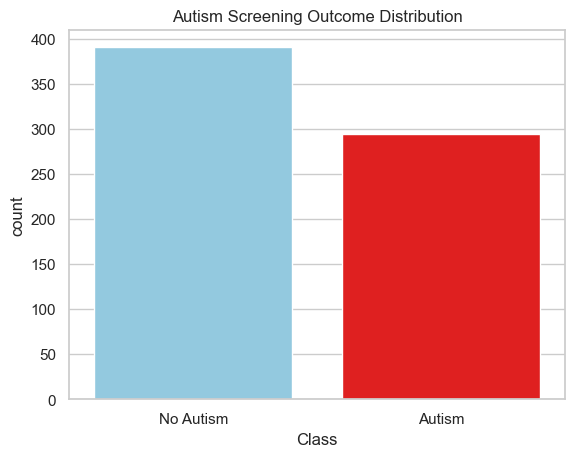

In [33]:
#NO OF INDIVIDUALS WITHOUT AUTISM TRAITS
sns.countplot(x="class_label", data=eda_df, hue="class_label",
    palette={"No Autism": "skyblue", "Autism": "red"})
plt.title("Autism Screening Outcome Distribution")
plt.xlabel("Class")
plt.show()


> Bar chart showing the number of individuals in each outcome category.

### 4.3 Gender Analysis

In [34]:
eda_df["gender_label"] = eda_df["gender"].map({0: "Female", 1: "Male"})
#CONVERTING NUMBERS TO LABELS FOR EASY VISUALISATION

> Maps the numeric gender column to readable labels ('Male'/'Female') for visualisation.

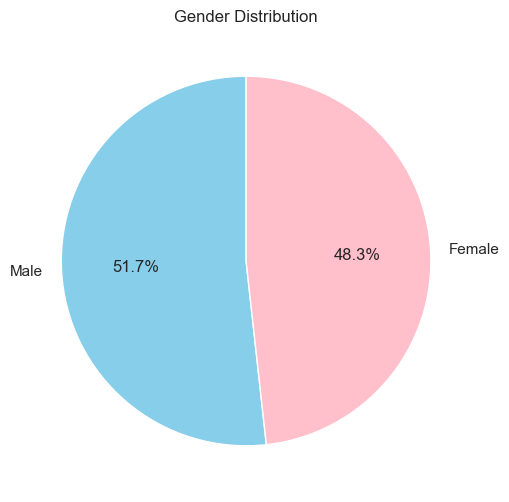

In [35]:
counts = eda_df["gender_label"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=["skyblue", "pink"], startangle=90)
plt.title("Gender Distribution")
plt.show()


> Pie chart showing the percentage split of male vs female participants in the dataset.

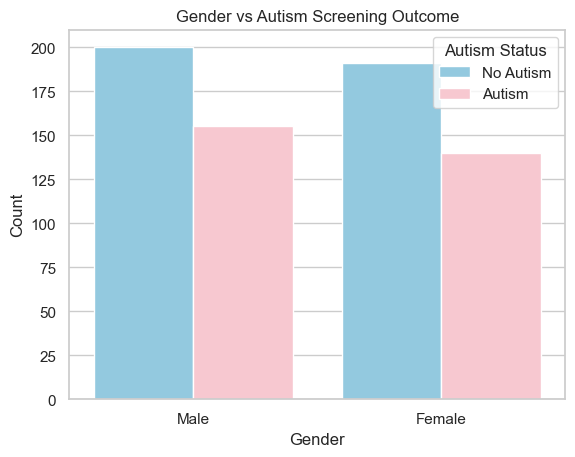

In [36]:
#CHECK IF ONE GENDER HAS HIGHER CRISIS
sns.countplot(x="gender_label", hue="class_label", data=eda_df,
    palette={"No Autism": "skyblue", "Autism": "pink"})
plt.title("Gender vs Autism Screening Outcome")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Autism Status")
plt.show()


> Grouped bar chart showing how autism screening outcomes differ between males and females.

### 4.4 Age Distribution

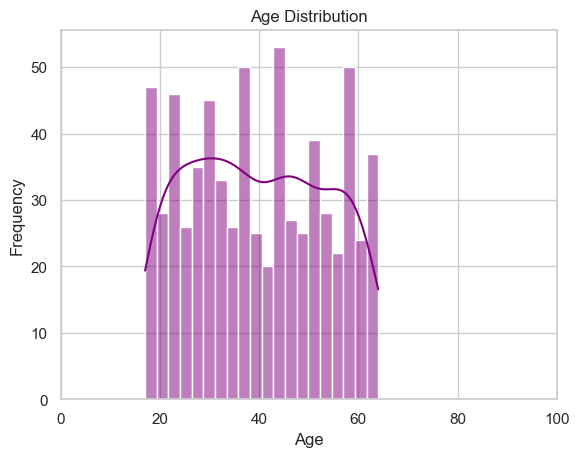

In [37]:
#AGE DISTRIBUTION
sns.histplot(eda_df["age"], bins=20, kde=True, color="purple")
plt.xlim(0, 100)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


> Histogram with a smoothed curve showing the age spread of all participants.

### 4.5 Feature Correlation Heatmap

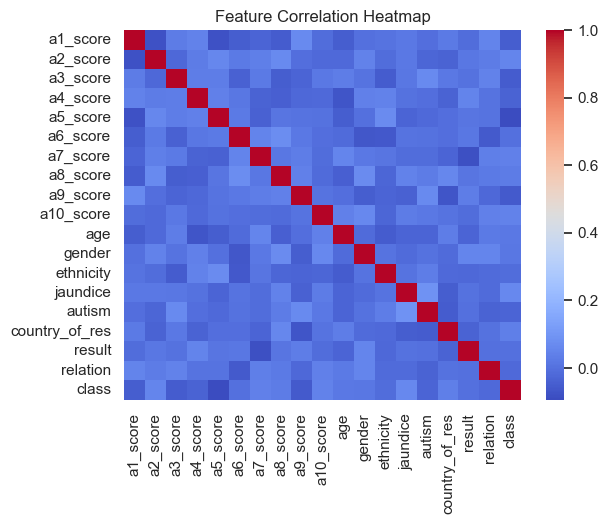

In [38]:
#CORRELATION HEATMAP OF ALL ATTRIBUTES
numeric_df = eda_df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


> Heatmap showing how strongly each feature correlates with every other feature — useful for spotting redundant columns.

### 4.6 Age Distribution by Autism Outcome

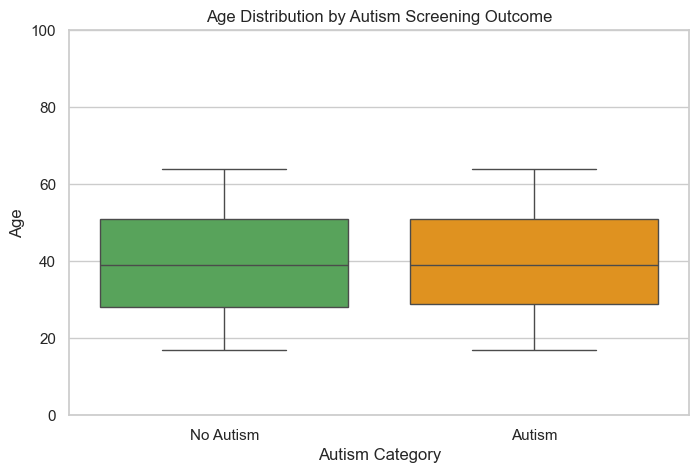

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x="class_label", y="age", data=eda_df, hue="class_label",
    palette={"No Autism": "#4CAF50", "Autism": "#FF9800"})
plt.ylim(0, 100)
plt.title("Age Distribution by Autism Screening Outcome")
plt.xlabel("Autism Category")
plt.ylabel("Age")
plt.show()


> Box plot comparing the age distribution of participants who screened positive vs negative for autism.

### 4.7 Autism Screening Proportion (Pie Chart)

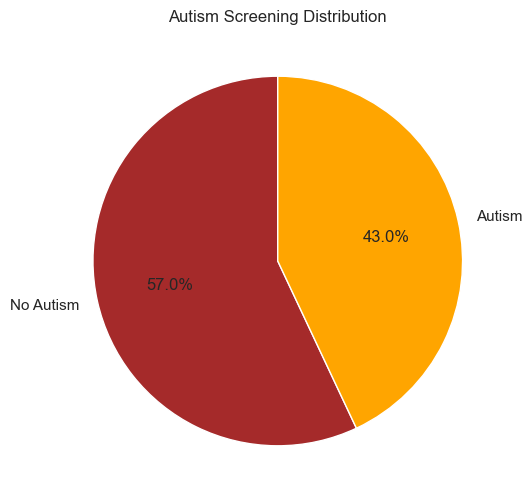

In [40]:
counts = eda_df["class_label"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=["brown", "orange"], startangle=90)
plt.title("Autism Screening Distribution")
plt.show()


> Pie chart showing the overall proportion of autism vs non-autism cases in the dataset.

## 5. Feature Engineering

Create additional features: total AQ-10 score and age group buckets.

In [41]:
# class column already contains numeric values from cleaning section
# No remapping needed here
print(df['class'].unique())

[0 1]


> Checks the current values in the 'class' column to avoid double-mapping errors.

In [42]:
#OVERALL AUTISM SCREENING SCORE
df["total_score"] = df[
    ["a1_score","a2_score","a3_score","a4_score","a5_score",
     "a6_score","a7_score","a8_score","a9_score","a10_score"]
].sum(axis=1)


> Sums all ten AQ-10 questionnaire item scores into a single total score per individual.

In [43]:
#AGE GROUPS
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 30, 50, 100],
    labels=["Teen", "Young Adult", "Adult", "Senior"]
)


> Groups participants into four age buckets (Teen, Young Adult, Adult, Senior) for easier analysis.

In [44]:
df = df.drop(columns=["class_label", "gender_label"], errors='ignore')

> Drops temporary label columns created during EDA that are no longer needed.

## 6. Model Training

Define features and target, apply train/test split, scale features, and train three classifiers: Logistic Regression, Decision Tree, and Random Forest.

### 6.1 Define Features (X) and Target (y)

In [45]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Encode any remaining non-numeric columns 
_numeric_types = {'int64', 'int32', 'float64', 'float32', 'bool'}
for col in df.columns:
    if df[col].dtype.name not in _numeric_types:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Define features X and target y (drop 'result' only if present)
drop_cols = [c for c in ['result', 'class'] if c in df.columns]
X = df.drop(columns=drop_cols)
y = df['class']

# Display shapes and sample data
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 values of y:")
print(y.head())


Feature matrix X shape: (686, 19)
Target vector y shape: (686,)

First 5 rows of X:
   a1_score  a2_score  a3_score  a4_score  a5_score  a6_score  a7_score  \
0         0         0         0         1         1         0         1   
1         1         0         1         0         0         0         1   
2         0         1         1         0         0         1         0   
3         0         1         1         1         1         1         1   
4         0         1         0         0         1         0         1   

   a8_score  a9_score  a10_score   age  gender  ethnicity  jaundice  autism  \
0         1         1          0  28.0       1          7         0       1   
1         0         1          0  40.0       0          5         1       0   
2         0         0          1  30.0       0          6         0       0   
3         0         0          1  21.0       1          6         1       1   
4         0         1          1  25.0       0          7         0   

> Verifies required columns exist, then separates features (X) from the target (y) and prints their shapes.

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['class'].astype(int))


> Re-encodes the string class labels into numeric 0/1 values using LabelEncoder.

### 6.2 Train/Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (548, 19)
Test shape: (138, 19)


> Splits data into 80% training and 20% test sets, keeping the class ratio the same in both (stratify).

### 6.3 Feature Scaling

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


> Scales all feature values to have mean 0 and standard deviation 1 — required for Logistic Regression to work well.

### 6.4 Train Classifiers

In [49]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


> Trains a Logistic Regression model on the scaled training data.

In [50]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree trained.")


Decision Tree trained.


> Trains a Decision Tree model on the unscaled training data.

In [51]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")


Random Forest trained.


> Trains a Random Forest (100 trees) on the unscaled training data.

## 7. Model Evaluation

Generate predictions and compute accuracy, precision, recall, F1-score, and ROC-AUC for each model.

### 7.1 Predictions

In [52]:
# Logistic Regression
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Decision Tree
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


> Generates class predictions and probability scores for all three models on the test set.

### 7.2 Evaluation Metrics

In [53]:
#MTERICS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1-score":  f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_prob)
    }


> Defines a helper function that computes Accuracy, Precision, Recall, F1-score, and ROC-AUC for any model.

In [54]:
#EVALUATION
results = {
    "Logistic Regression": evaluate_model(y_test, y_pred_log, y_prob_log),
    "Decision Tree":       evaluate_model(y_test, y_pred_dt,  y_prob_dt),
    "Random Forest":       evaluate_model(y_test, y_pred_rf,  y_prob_rf)
}

results_df = pd.DataFrame(results).T.round(4)
print("\n=== Model Evaluation Results ===")
print(results_df.to_string())



=== Model Evaluation Results ===
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.5072     0.4000  0.3051    0.3462   0.4608
Decision Tree          0.5362     0.4545  0.4237    0.4386   0.5220
Random Forest          0.5290     0.4286  0.3051    0.3564   0.5057


> Runs the evaluation function for all three models and prints a side-by-side comparison table.

### 7.2b Confusion Matrices


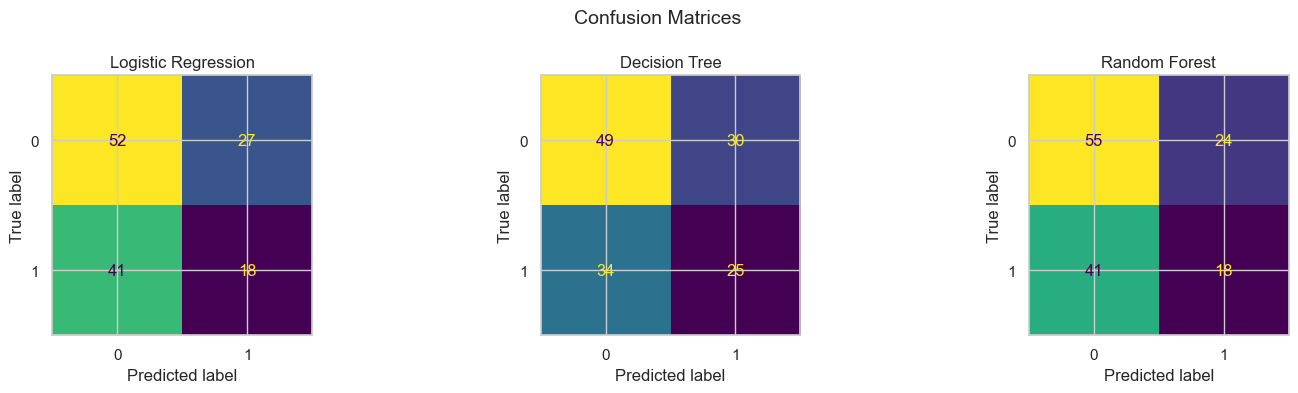

In [55]:
# CONFUSION MATRICES
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_names = ["Logistic Regression", "Decision Tree", "Random Forest"]
preds       = [y_pred_log, y_pred_dt, y_pred_rf]

for ax, name, pred in zip(axes, model_names, preds):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()


> Plots a confusion matrix for each model, showing counts of correct and incorrect predictions per class.

### 7.2c ROC Curves


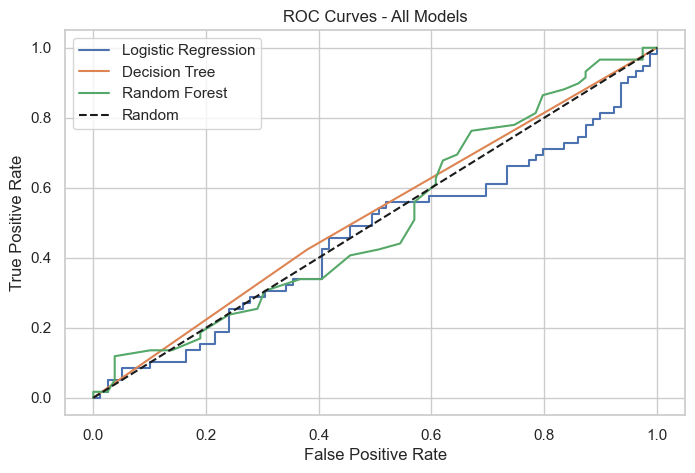

In [56]:
# ROC CURVES
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for name, y_prob in zip(
    ["Logistic Regression", "Decision Tree", "Random Forest"],
    [y_prob_log, y_prob_dt, y_prob_rf]
):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.show()


> Plots ROC curves for all three models on the same axes — the higher the curve, the better the model.

### 7.3 Cross-Validation

In [57]:
#CROSS VALIDATION
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv)

print("Cross-validation accuracy:", cv_scores.mean())


Cross-validation accuracy: 0.5437127024722932


> Runs 10-fold cross-validation on the Random Forest to get a more reliable estimate of its accuracy.

### 7.4 Dataset Balance Check

In [58]:
import numpy as np
print(np.unique(y, return_counts=True))
#CHECK DATASET BALANCE/IMBALANCE

(array([0, 1]), array([391, 295]))


> Prints the exact class counts in y to confirm whether the data is balanced or imbalanced.

## 8. Feature Importance & Explainability

### 8.1 Random Forest Feature Importance (Bar Chart)

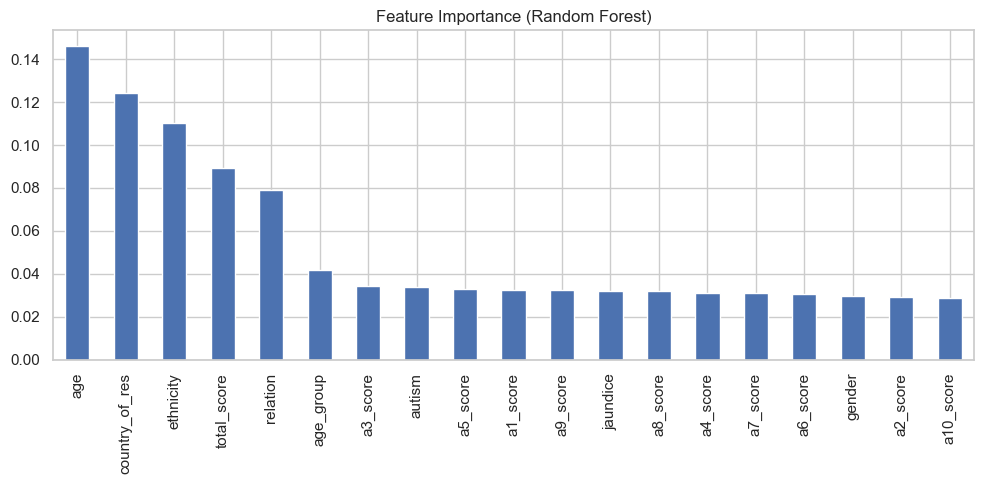

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()


> Bar chart ranking all features by how much the Random Forest relied on each one during training.

### 8.2 SHAP Global Summary Plot

Use SHAP (SHapley Additive exPlanations) to explain the model's predictions across the test set.


=== Top Features by Mean |SHAP| Value ===
a5_score          0.0368
a2_score          0.0239
country_of_res    0.0227
jaundice          0.0209
autism            0.0207
age               0.0180
ethnicity         0.0157
a7_score          0.0136
relation          0.0130
total_score       0.0125
a3_score          0.0115
age_group         0.0108
a1_score          0.0105
gender            0.0089
a10_score         0.0087
a6_score          0.0086
a4_score          0.0082
a9_score          0.0069
a8_score          0.0064


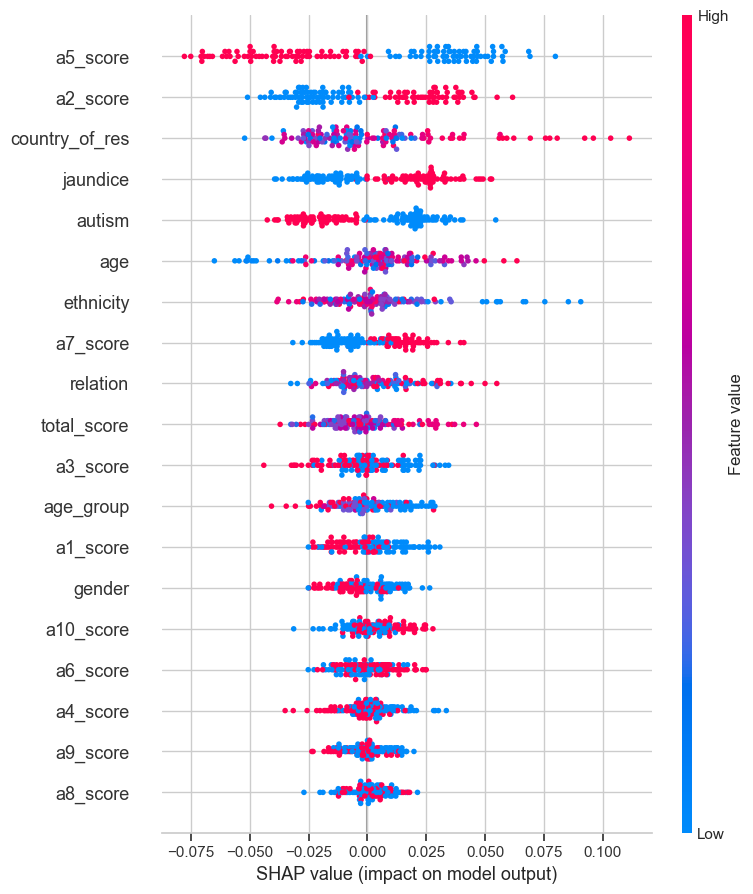

In [60]:
                                #SHAP IMPLEMENTATION
try:
    import shap

    shap.initjs()

    explainer   = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test)

    # shap_values is a list [class0, class1] or 3-D array depending on version
    if isinstance(shap_values, list):
        sv_class1 = shap_values[1]       # shape (n_samples, n_features)
    else:
        sv_class1 = shap_values[:, :, 1] # 3-D array

    # Print mean absolute SHAP values (feature impact ranking)
    shap_importance = pd.Series(
        np.abs(sv_class1).mean(axis=0),
        index=X_test.columns
    ).sort_values(ascending=False)
    print("\n=== Top Features by Mean |SHAP| Value ===")
    print(shap_importance.round(4).to_string())

    shap.summary_plot(sv_class1, X_test)

except ImportError:
    print("SHAP is not installed. Run:  pip install shap")
    print("Feature importance bar chart (Section 8.1) remains available.")


> Uses SHAP TreeExplainer to calculate how much each feature pushed predictions up or down across all test samples, then prints a ranked summary.

### 8.3 SHAP Local Force Plot

Explain a single prediction (index 0) using a SHAP force plot.

Explaining prediction for test sample index 0
Predicted class: 0
Actual class:    0


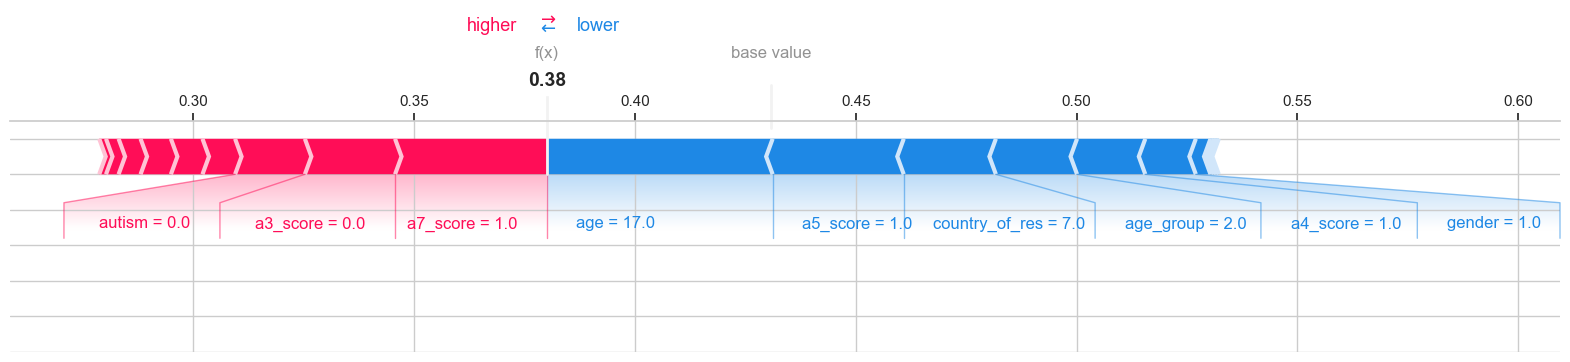

In [61]:
                               #SHAP IMPLEMENTATION (LOCAL)
try:
    index = 0

    print(f"Explaining prediction for test sample index {index}")
    print(f"Predicted class: {le.inverse_transform([rf_model.predict(X_test)[index]])[0]}")
    print(f"Actual class:    {le.inverse_transform([y_test[index]])[0]}")

    shap.force_plot(
        explainer.expected_value[1],
        sv_class1[index],
        X_test.iloc[index],
        matplotlib=True
    )

except NameError:
    print("SHAP explainer not available — skipping local force plot.")


> Shows a SHAP force plot for a single test sample, explaining exactly why the model made that specific prediction.

## 9. Feature Reduction Experiment

Train on only the top 5 most important features and compare cross-validated accuracy against the full model.

In [62]:
#      FEATURE REDUCTION EXPERIMENT
top_features = feat_importance.sort_values(ascending=False).head(5).index

X_reduced = X[top_features]

from sklearn.model_selection import cross_val_score
scores_reduced = cross_val_score(rf_model, X_reduced, y, cv=5)
scores_full    = cross_val_score(rf_model, X,         y, cv=5)

print("\n=== Feature Reduction Experiment ===")
print(f"Top 5 features used: {list(top_features)}")
print(f"Reduced model CV accuracy: {scores_reduced.mean():.4f}")
print(f"Full model CV accuracy:    {scores_full.mean():.4f}")
print(f"Accuracy drop:             {scores_full.mean() - scores_reduced.mean():.4f}")



=== Feature Reduction Experiment ===
Top 5 features used: ['age', 'country_of_res', 'ethnicity', 'total_score', 'relation']
Reduced model CV accuracy: 0.5000
Full model CV accuracy:    0.5146
Accuracy drop:             0.0146


> Retrains the model using only the top 5 features and compares its cross-validated accuracy to the full model.